# Everything, at the operating points that matter

One notebook holding the whole result set: **AUROC and TPR at 1, 5 and 10 percent
FPR**, for every operator, every position, every attack, every dataset, both
architectures.

## Why the operating point is the headline, not AUROC

AUROC summarises the whole ROC curve, including regions no deployment would ever
run in. A detector screening real traffic runs at a false positive rate the
business can absorb, which is 1 or 5 percent, not 25.

The gap between those views is large and it is not in our favour. The deployment
configuration scores **AUROC 0.826** on the CIFAR-100 1 percent panel and
**TPR 0.124 at 1 percent FPR**. Both are true. Only one of them describes what
happens if you turn it on.

The 25 percent quantile that PSBD's paper reports, and that this project inherited
as its headline, discards **a quarter of clean traffic**. That is a choice, not a
measurement: the quantile sets the false positive rate mechanically, so the only
question the number answers is how much of the backdoor falls below the same line.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# One row per placement, rate, PSU variant and quantile. Built by
# `python -m cli.summary --operating-points`, which reads the per-rate blocks that
# already record all 6 quantiles rather than recomputing anything.
points = pd.read_csv("results/operating_points.csv")

# The rows that can be pooled: a plain measurement whose stage-1 tensors still
# exist. See notebook 12 for why this filter is not optional.
points = points[points["variant"].isna() & points["cache_backed"]]

# Adaptive-attacker checkpoints are a different question and belong in notebook 11.
# Pooling them here drags the deployment configuration from 0.826 to 0.587.
points = points[~points["folder"].str.contains("evade")]

print(f"{len(points):,} rows, {points['folder'].nunique()} checkpoints")
print(f"quantiles: {sorted(points['quantile'].unique())}")
print(f"PSU variants: {sorted(points['psu_variant'].unique())}")

632,952 rows, 163 checkpoints
quantiles: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]
PSU variants: ['absolute', 'captured_only', 'fractional']


## Reading a placement at a matched disturbance

Two placements can only be compared at a matched clean-validation shift ratio,
because the same nominal rate is a different amount of disturbance at different
sites. Everything below picks, per checkpoint, the swept rate whose validation
shift ratio lands nearest the target, and carries the achieved value so a
mismatch is visible rather than hidden.

In [2]:
from psbd.decision import ADAPTIVE_SHIFT_TARGET, PLACEMENT_MATCH_TARGET

# This notebook asks 2 questions that need 2 different rate rules, and collapsing
# them into one helper is how an earlier draft reported detection numbers at a
# placement-comparison target and lost 0.126 TPR@1%FPR without anything failing.
#
# "Is placement A better than placement B" needs both arms perturbed equally hard,
# or the answer is just "which one perturbs harder". That is matched strength:
# the swept rate NEAREST the target, at PLACEMENT_MATCH_TARGET.
#
# "What does a defender get" needs a rule a defender can execute knowing only clean
# data. That is PSBD's own: the SMALLEST rate REACHING ADAPTIVE_SHIFT_TARGET. Never
# nearest, because a rate that lands just under the target is not one the rule would
# have picked.
#
# Every table below names which it used.


def at_matched_strength(frame, target=PLACEMENT_MATCH_TARGET):
    """For comparing placements: the swept rate nearest the target shift ratio."""
    usable = frame.dropna(subset=["sigma_validation"]).copy()
    usable["gap"] = (usable["sigma_validation"] - target).abs()
    keys = ["folder", "placement", "psu_variant", "quantile"]
    return usable.loc[usable.groupby(keys)["gap"].idxmin()]


def at_deployable_rate(frame, target=ADAPTIVE_SHIFT_TARGET):
    """For reporting detection: PSBD's rule, smallest rate reaching the target.

    A cell whose sweep never reaches the target drops out rather than falling back
    to its closest rate, because the rule genuinely has no answer there and a
    silent substitution would be a different protocol wearing this one's name.
    """
    usable = frame.dropna(subset=["sigma_validation"])
    reaching = usable[usable["sigma_validation"] >= target]
    keys = ["folder", "placement", "psu_variant", "quantile"]
    return reaching.loc[reaching.groupby(keys)["rate"].idxmin()]


def operating_table(frame, group, rule=at_deployable_rate):
    """AUROC once, TPR at each quantile, plus the achieved shift ratio."""
    chosen = rule(frame)
    wide = (
        chosen.pivot_table(index=group, columns="quantile", values="tpr", aggfunc="mean")
        .rename(columns=lambda q: f"TPR@{q:.0%}FPR")
    )
    wide["AUROC"] = chosen.groupby(group)["auroc"].mean()
    wide["sigma"] = chosen.groupby(group)["sigma_validation"].mean()
    wide["n"] = chosen.groupby(group)["folder"].nunique()
    return wide


The deployable rule refuses to answer where the sweep never reached the target,
and refusing is not free: it removes cells rather than downgrading them. That has to
be measured before any table below is read, because a rule that quietly drops its
hard cases reports a number for an easier population than the one it claims.

In [3]:
both = points[(points["psu_variant"] == "fractional") & (points["asr"] >= 0.5)]
cells = ["folder", "placement"]
reach = (
    both.groupby(cells)["sigma_validation"].max().rename("max sigma reached").reset_index()
)
reach["reaches deployable target"] = reach["max sigma reached"] >= ADAPTIVE_SHIFT_TARGET
reach["reaches matched target"] = reach["max sigma reached"] >= PLACEMENT_MATCH_TARGET

print(f"{len(reach):,} (checkpoint, placement) cells in the fractional panel")
print(f"  reach sigma {ADAPTIVE_SHIFT_TARGET} (deployable rule): "
      f"{reach['reaches deployable target'].sum():,} "
      f"({reach['reaches deployable target'].mean():.1%})")
print(f"  reach sigma {PLACEMENT_MATCH_TARGET} (matched rule):    "
      f"{reach['reaches matched target'].sum():,} "
      f"({reach['reaches matched target'].mean():.1%})")
print()
dropped = reach[~reach["reaches deployable target"]]
if len(dropped):
    print("placements the deployable rule cannot report on, and how far they got:")
    print(dropped.groupby("placement")["max sigma reached"]
          .agg(["count", "max"]).sort_values("count", ascending=False).round(3).to_string())
else:
    print("no cell drops out: every placement reaches the deployable target somewhere")

3,362 (checkpoint, placement) cells in the fractional panel
  reach sigma 0.8 (deployable rule): 3,244 (96.5%)
  reach sigma 0.6 (matched rule):    3,264 (97.1%)

placements the deployable rule cannot report on, and how far they got:
                            count    max
placement                               
final_norm_out_gain_scale      94  0.005
input_pixels_scale_up          10  0.799
before_attention_gaussian       9  0.768
mlp_neurons_gaussian            2  0.795
before_attention_norm           1  0.055
post_residual_channel_mask      1  0.780
pre_residual                    1  0.664


A placement that cannot be driven to the target at any swept rate is not a
placement a defender can deploy under PSBD's rule, so its absence from the deployment
tables is the correct answer rather than missing data. It still appears in the
matched-strength tables, which is why those two families of table have different `n`
and must not be read across.

## 1. The deployment configuration, across every attack

`token_mask` at `before_attention_norm`, fractional PSU, read at matched shift
ratio 0.6. One row per attack so the spread is visible rather than averaged away.

**Scope: this table pools ViT and Swin.** Notebook 14 reports the same
configuration for ViT alone and reads lower on several attacks, which is not a
disagreement. Swin scores at or above ViT on every attack it covers (`lc` 0.915
against 0.739 at 25% FPR, `adaptive_blend` 0.942 against 0.889), so pooling lifts
the mean wherever Swin checkpoints exist. Swin covers 5 of the 9 attacks, so the
lift is uneven across rows and the 2 notebooks' columns must not be read across.


In [4]:
DEPLOY = "before_attention_norm_token_mask"
deploy = points[
    (points["placement"] == DEPLOY)
    & (points["psu_variant"] == "fractional")
    & (points["asr"] >= 0.5)
]
by_attack = operating_table(deploy, "attack").sort_values("AUROC", ascending=False)
by_attack.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
attack,,,,,,,,,
badnet_a2o,0.820,0.970,0.989,0.996,0.998,0.999,0.993,0.872,15
blend,0.862,0.931,0.954,0.969,0.977,0.982,0.982,0.869,15
bpp,0.891,0.944,0.964,0.973,0.977,0.979,0.981,0.873,12
lf,0.906,0.961,0.970,0.975,0.977,0.978,0.978,0.882,10
adaptive_blend,0.860,0.891,0.895,0.896,0.898,0.898,0.906,0.863,12
wanet,0.296,0.664,0.746,0.811,0.847,0.867,0.888,0.865,10
lc,0.312,0.480,0.597,0.698,0.757,0.798,0.839,0.876,9
sig,0.163,0.214,0.247,0.276,0.310,0.349,0.579,0.822,2
badnet_a2a,0.009,0.023,0.045,0.075,0.110,0.155,0.414,0.853,9


The `TPR@1%FPR` column is the one to read first. An attack with AUROC above 0.9
and TPR near 0 at 1 percent FPR is not detectable in deployment, it is only
separable in principle.

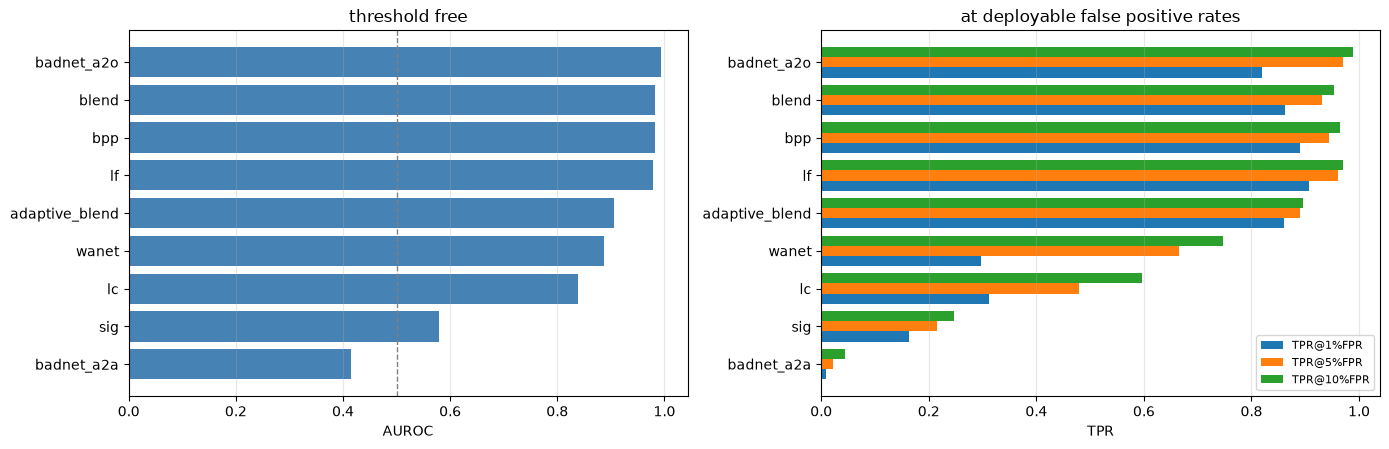

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ordered = by_attack.sort_values("AUROC")
positions = np.arange(len(ordered))

axes[0].barh(positions, ordered["AUROC"], color="steelblue")
axes[0].axvline(0.5, ls="--", lw=1, c="grey")
axes[0].set_yticks(positions); axes[0].set_yticklabels(ordered.index)
axes[0].set_xlabel("AUROC"); axes[0].set_title("threshold free")

width = 0.27
for offset, quantile in zip((-width, 0, width), (0.01, 0.05, 0.10)):
    column = f"TPR@{quantile:.0%}FPR"
    axes[1].barh(positions + offset, ordered[column], height=width, label=column)
axes[1].set_yticks(positions); axes[1].set_yticklabels(ordered.index)
axes[1].set_xlabel("TPR"); axes[1].set_title("at deployable false positive rates")
axes[1].legend(fontsize=8)
for axis in axes:
    axis.grid(alpha=0.3, axis="x")
figure.tight_layout()
plt.show()

## 2. Every operator, at every position

The full grid. `n` is how many checkpoints contributed, and a small `n` is a
reason to distrust a row rather than to quote it.

In [6]:
grid = points[(points["psu_variant"] == "fractional") & (points["asr"] >= 0.5)]
full = operating_table(grid, ["position", "operator"], rule=at_matched_strength)
full = full[full["n"] >= 8].sort_values("AUROC", ascending=False)
pd.set_option("display.max_rows", 60)
full.round(3)

,quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
position,operator,,,,,,,,,
both_sublayer_inputs,token_mask,0.347,0.616,0.712,0.789,0.840,0.871,0.886,0.648,48
before_attention,gaussian,0.498,0.691,0.768,0.802,0.826,0.844,0.886,0.628,9
mlp_neurons,gaussian,0.307,0.558,0.678,0.744,0.784,0.811,0.866,0.767,9
before_attention_norm,token_mask,0.416,0.670,0.740,0.774,0.800,0.823,0.860,0.583,94
before_attention,dropout,0.341,0.590,0.651,0.701,0.737,0.770,0.842,0.669,31
post_residual,channel_mask,0.517,0.635,0.694,0.729,0.755,0.776,0.837,0.731,68
before_mlp_residual,dropout,0.246,0.507,0.638,0.698,0.738,0.770,0.825,0.595,121
pre_residual,channel_mask,0.287,0.515,0.623,0.687,0.737,0.772,0.824,0.649,64
before_mlp,gaussian,0.148,0.485,0.641,0.711,0.739,0.759,0.820,0.506,30


## 3. Where a probe must not go

Three separate failure modes, and they are not interchangeable.

**Inert by construction.** `token_mask` after the final norm cannot reach anything
the classifier reads, because ViT's head reads token 0 alone and `token_mask`
protects token 0. PSU would be identically 0 and AUROC exactly 0.5, which reads as
"this position does not matter" rather than "this probe never fired".
`psbd.operators.check_operator_position` refuses it.

**Wrong axis.** `input_pixels` carries a `(batch, channels, height, width)` image,
and the token operators read a rank-4 tensor as Swin's
`(batch, height, width, channels)`. `token_mask` there masks image rows
independently per colour channel. It runs, and it answers a different question.

**No information left to find.** A probe at the classifier head is the confidence
null. The closed form for the Hessian trace of the predicted class probability
depends on nothing but the softmax vector, so a probe there can carry nothing that
free max-softmax confidence does not already have. Measured, the two agree to
within 0.003.

In [7]:
from psbd.operators import check_operator_position

for operator, position in (
    ("token_mask", "final_norm_out"),
    ("token_mask", "input_pixels"),
    ("channel_mask", "input_pixels"),
    ("head_mask", "before_mlp"),
    ("token_mask", "before_attention_norm"),
):
    try:
        check_operator_position(operator, position)
        print(f"  ALLOWED  {operator:13s} @ {position}")
    except ValueError as error:
        print(f"  REFUSED  {operator:13s} @ {position}\n           {str(error)[:96]}...")

  REFUSED  token_mask    @ final_norm_out
           token_mask at final_norm_out: final_norm_out sits after the final LayerNorm, and ViT's head read...
  REFUSED  token_mask    @ input_pixels
           token_mask at input_pixels: input_pixels carries a (batch, channels, height, width) image, and t...
  REFUSED  channel_mask  @ input_pixels
           channel_mask at input_pixels: input_pixels carries a (batch, channels, height, width) image, and...
  REFUSED  head_mask     @ before_mlp
           head_mask is only meaningful at ('attention_heads',), not at 'before_mlp'...
  ALLOWED  token_mask    @ before_attention_norm


In [8]:
# The head position, measured rather than argued. gain_scale is the only operator
# swept there, so the comparison is against the confidence null on the same cells.
head = points[(points["position"] == "final_norm_out") & (points["psu_variant"] == "fractional")]
if len(head):
    print(operating_table(head, "operator", rule=at_matched_strength).round(3).to_string())
    print()
    print("A probe here scores at or below chance. Notebook 12 and audit A18 show")
    print("why: at the logits the statistic is a function of the softmax vector")
    print("alone, so it cannot beat the free confidence baseline it reduces to.")
else:
    print("no cache-backed rows at final_norm_out in the filtered set")

quantile    TPR@1%FPR  TPR@5%FPR  TPR@10%FPR  TPR@15%FPR  TPR@20%FPR  TPR@25%FPR  AUROC  sigma    n
operator                                                                                           
gain_scale      0.005      0.041       0.098       0.149       0.197       0.239   0.44  0.001  101

A probe here scores at or below chance. Notebook 12 and audit A18 show
why: at the logits the statistic is a function of the softmax vector
alone, so it cannot beat the free confidence baseline it reduces to.


## 4. Depth: one band of layers, or all of them

Everything above perturbs a position in **every** block. The depth-band sweep asks
a different question: what if the probe is restricted to a contiguous span?

This matters because where a trigger's signal reaches the residual stream is
attack-dependent. A patch trigger and a blended trigger do not crystallize at the
same depth, so perturbing all 12 blocks cannot distinguish "this position matters"
from "this depth matters". Those are different claims.

The bands are restrictions of `pre_residual`, so `pre_residual` itself is the
all-blocks control and the comparison is like for like.

In [9]:
depth_source = pd.read_csv("results/operating_points.csv")
depth_source = depth_source[
    depth_source["cache_backed"]
    & (~depth_source["folder"].str.contains("evade"))
    & (depth_source["psu_variant"] == "fractional")
    & (depth_source["asr"] >= 0.5)
    & (depth_source["position"] == "pre_residual")
]

# The all-blocks control is the plain placement; the bands carry a variant tag.
depth_source["band"] = depth_source["variant"].fillna("all blocks")
vit_depth = depth_source[depth_source["architecture"] == "vit"]

BAND_ORDER = ["blocks_1_4", "blocks_5_8", "blocks_9_12", "all blocks"]
depth = operating_table(vit_depth, "band", rule=at_matched_strength)
depth = depth.reindex([b for b in BAND_ORDER if b in depth.index])
depth.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
band,,,,,,,,,
blocks_1_4,0.150,0.334,0.443,0.536,0.619,0.669,0.771,0.588,76
blocks_5_8,0.380,0.664,0.751,0.798,0.826,0.844,0.866,0.565,76
blocks_9_12,0.623,0.701,0.740,0.768,0.788,0.806,0.852,0.415,76
all blocks,0.207,0.399,0.506,0.583,0.644,0.691,0.781,0.635,92


Read the `n` column before the rest. Then read down the `AUROC` column against the
`all blocks` row, which is the control.

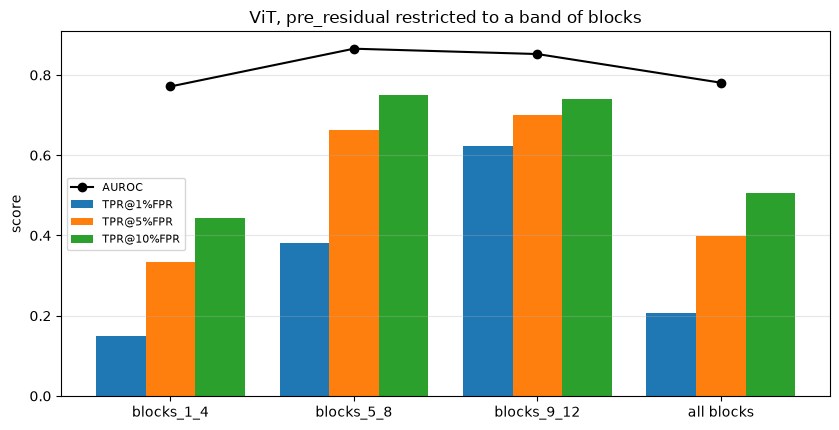

In [10]:
figure, axis = plt.subplots(figsize=(8.5, 4.4))
present = [b for b in BAND_ORDER if b in depth.index]
positions = np.arange(len(present))
width = 0.27
for offset, quantile in zip((-width, 0, width), (0.01, 0.05, 0.10)):
    axis.bar(positions + offset, depth.loc[present, f"TPR@{quantile:.0%}FPR"],
             width=width, label=f"TPR@{quantile:.0%}FPR")
axis.plot(positions, depth.loc[present, "AUROC"], marker="o", color="black", label="AUROC")
axis.set_xticks(positions); axis.set_xticklabels(present)
axis.set_ylabel("score"); axis.set_title("ViT, pre_residual restricted to a band of blocks")
axis.legend(fontsize=8); axis.grid(alpha=0.3, axis="y")
figure.tight_layout()
plt.show()

### Does the best band depend on the attack?

This is the question that decides whether depth is a tuning knob or a property of
the trigger. If different attacks peak in different bands, a single deployed depth
is a compromise and the paper has to say so.

In [11]:
per_attack_band = operating_table(vit_depth, ["attack", "band"], rule=at_matched_strength)
per_attack_band = per_attack_band[per_attack_band["n"] >= 2]

auroc_grid = (
    per_attack_band["AUROC"]
    .unstack("band")
    .reindex(columns=[b for b in BAND_ORDER if b in per_attack_band.index.get_level_values("band")])
)
auroc_grid["best band"] = auroc_grid.idxmax(axis=1)
auroc_grid["best minus all blocks"] = (
    auroc_grid.drop(columns=["best band"]).max(axis=1) - auroc_grid["all blocks"]
)
auroc_grid.round(3)

band,blocks_1_4,blocks_5_8,blocks_9_12,all blocks,best band,best minus all blocks
attack,,,,,,
adaptive_blend,0.795,0.910,0.864,0.806,blocks_5_8,0.104
badnet_a2a,0.384,0.246,0.146,0.327,blocks_1_4,0.057
badnet_a2o,0.773,0.897,0.786,0.827,blocks_5_8,0.071
blend,0.878,0.911,0.983,0.877,blocks_9_12,0.106
bpp,0.874,0.944,0.968,0.878,blocks_9_12,0.090
lc,0.624,0.816,0.640,0.621,blocks_5_8,0.195
lf,0.810,0.938,0.975,0.872,blocks_9_12,0.103
sig,NaN,NaN,NaN,0.729,all blocks,0.000
wanet,0.558,0.931,0.960,0.758,blocks_9_12,0.202


In [12]:
best_counts = auroc_grid["best band"].value_counts()
print("which band wins, counted over attacks:")
print(best_counts.to_string())
print()
gains = auroc_grid["best minus all blocks"]
print(f"attacks where a single band beats all-blocks: {(gains > 0.01).sum()} of {len(gains)}")
print(f"median gain from choosing the best band: {gains.median():+.3f}")
print(f"largest gain: {gains.max():+.3f} on {gains.idxmax()}")
print(f"largest loss: {gains.min():+.3f} on {gains.idxmin()}")

which band wins, counted over attacks:
best band
blocks_9_12    4
blocks_5_8     3
blocks_1_4     1
all blocks     1

attacks where a single band beats all-blocks: 8 of 9
median gain from choosing the best band: +0.103
largest gain: +0.202 on wanet
largest loss: +0.000 on sig


### What restricting the probe costs

A band perturbs fewer blocks, so at the same nominal rate it delivers less total
disturbance. If the bands are read at a lower shift ratio than the all-blocks
control, part of any difference is strength rather than depth, which is the
confound that sank the old headline. The `sigma` column above is what makes that
checkable.

In [13]:
strength = depth[["sigma", "AUROC", "n"]].copy()
strength["sigma minus all blocks"] = strength["sigma"] - depth.loc["all blocks", "sigma"]
print(strength.round(3).to_string())
print()
worst = strength["sigma minus all blocks"].abs().max()
print(f"largest strength mismatch against the control: {worst:.3f}")
print(
    "Under about 0.05 the bands are genuinely comparable to all-blocks. Above it,\n"
    "part of the difference is how hard each was hit and the comparison is not clean."
)

quantile     sigma  AUROC   n  sigma minus all blocks
band                                                 
blocks_1_4   0.588  0.771  76                  -0.047
blocks_5_8   0.565  0.866  76                  -0.070
blocks_9_12  0.415  0.852  76                  -0.220
all blocks   0.635  0.781  92                   0.000

largest strength mismatch against the control: 0.220
Under about 0.05 the bands are genuinely comparable to all-blocks. Above it,
part of the difference is how hard each was hit and the comparison is not clean.


## 5. Which PSU variant to report

Three are recorded. They answer different questions and should not be mixed inside
one table.

- **absolute** is the paper's form, a raw drop in confidence.
- **fractional** divides by the starting confidence, which removes the objection
  that PSU is really measuring how confident a prediction began.
- **captured only** restricts **both** splits to the images the trigger actually
  flipped. A triggered image the model still classifies correctly is behaviourally
  clean, so scoring it as a detection positive charges the detector for the
  attack's failure. Both sides must be restricted; restricting only the backdoor
  side compares hard images against easy ones and reported 0.921 for a benign
  control that scores 0.505 when done correctly.

In [14]:
variants = points[(points["placement"] == DEPLOY) & (points["asr"] >= 0.5)]
by_variant = operating_table(variants, "psu_variant")
by_variant.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
psu_variant,,,,,,,,,
absolute,0.600,0.708,0.756,0.796,0.829,0.854,0.901,0.868,94
captured_only,0.623,0.736,0.781,0.818,0.848,0.871,0.914,0.868,94
fractional,0.654,0.763,0.797,0.822,0.838,0.851,0.887,0.868,94


## 6. Coverage, before any of the above is averaged

An average over an unequal grid is not the number it appears to be, and this
project has had conclusions inverted by exactly that. Swin has no GTSRB rows here:
40 checkpoints are trained and were never swept, and that sweep is running.

In [15]:
coverage = (
    points.groupby(["architecture", "dataset"])
    .agg(checkpoints=("folder", "nunique"), placements=("placement", "nunique"))
    .reset_index()
)
print(coverage.to_string(index=False))
print()
print("Any mean over datasets currently averages 4 for vit and 3 for swin.")

architecture  dataset  checkpoints  placements
        swin  cifar10           25           7
        swin cifar100           27           9
         vit  cifar10           40          51
         vit cifar100           27          39
         vit    gtsrb           22          36
         vit     tiny           22          36

Any mean over datasets currently averages 4 for vit and 3 for swin.


## What to take away

**Report the operating point, not just AUROC.** The deployment configuration is
AUROC 0.826 and TPR 0.124 at 1 percent FPR on the CIFAR-100 1 percent panel. A
reader given only the first number would form the wrong impression of what
happens when it is switched on.

**The 25 percent quantile is a choice about clean loss, not a result.** It fixes
the false positive rate mechanically. The only thing it measures is how much
backdoor falls below the same line.

**Three places a probe must not go**, for three different reasons: inert by
construction at the final norm, wrong axis at the input pixels, and no information
left to find at the classifier head, where the statistic reduces to free
confidence.

**Depth is attack-dependent**, so a single deployed band is a compromise. The
tables above say by how much, and the strength check says whether the comparison
was clean.

---

# Part II. The rate curve, and the best configuration for every attack

Everything above reads each placement at one matched disturbance. This part varies
the rate and reports the whole curve, then asks what the best achievable
configuration is for each attack and what it costs to deploy one configuration
instead.

## 7. What happens as you turn the rate up

The rate is the knob. Turning it up perturbs the model harder, which raises the
shift ratio, which changes both how much clean confidence falls and how much
backdoor confidence falls. There is an optimum and it is not at either end.

Plotted against the **nominal rate** first, which is what a user sets, and then
against the **achieved shift ratio**, which is what the model experiences and the
only x-axis on which two operators can be compared.

In [16]:
CURVE_PLACEMENTS = [
    "before_attention_norm_token_mask",
    "before_mlp_token_mask",
    "pre_residual",
    "before_attention_norm",
    "before_mlp_gaussian",
    "before_attention_channel_mask",
]

curve = points[
    (points["psu_variant"] == "fractional")
    & (points["asr"] >= 0.5)
    & (points["placement"].isin(CURVE_PLACEMENTS))
    & (points["architecture"] == "vit")
]

# AUROC does not depend on the quantile, so it is read from one of them.
auroc_curve = (
    curve[curve["quantile"] == 0.25]
    .groupby(["placement", "rate"])
    .agg(auroc=("auroc", "mean"), sigma=("sigma_validation", "mean"), n=("folder", "nunique"))
    .reset_index()
)
auroc_curve = auroc_curve[auroc_curve["n"] >= 8]
print(f"{auroc_curve['placement'].nunique()} placements, "
      f"{auroc_curve['rate'].nunique()} distinct rates")
auroc_curve.head(10).round(3)

6 placements, 15 distinct rates


,placement,rate,auroc,sigma,n
0,before_attention_channel_mask,0.05,0.589,0.057,81
1,before_attention_channel_mask,0.10,0.600,0.098,81
2,before_attention_channel_mask,0.20,0.616,0.179,81
3,before_attention_channel_mask,0.30,0.647,0.286,81
4,before_attention_channel_mask,0.40,0.689,0.497,81
5,before_attention_channel_mask,0.50,0.767,0.684,81
6,before_attention_channel_mask,0.60,0.822,0.847,81
7,before_attention_channel_mask,0.70,0.841,0.933,81
8,before_attention_channel_mask,0.80,0.797,0.958,81
9,before_attention_channel_mask,0.90,0.695,0.963,81


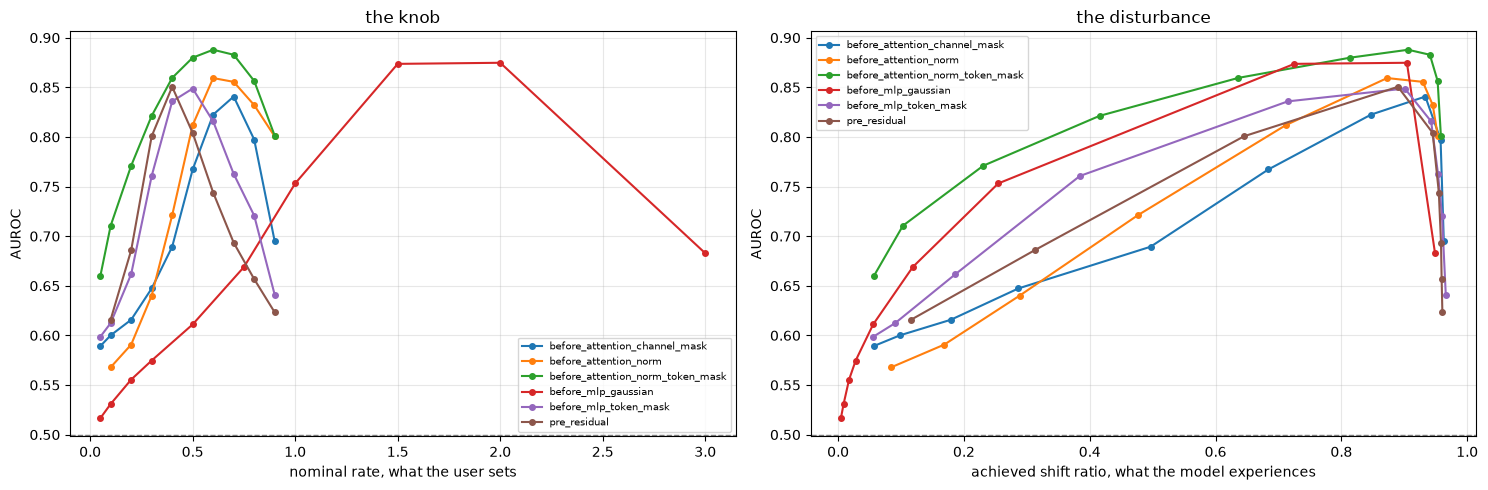

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
for placement, group in auroc_curve.groupby("placement"):
    group = group.sort_values("rate")
    axes[0].plot(group["rate"], group["auroc"], marker="o", markersize=4, label=placement)
    group = group.sort_values("sigma")
    axes[1].plot(group["sigma"], group["auroc"], marker="o", markersize=4, label=placement)

axes[0].set_xlabel("nominal rate, what the user sets")
axes[1].set_xlabel("achieved shift ratio, what the model experiences")
for axis in axes:
    axis.set_ylabel("AUROC")
    axis.axhline(0.5, ls="--", lw=1, c="grey")
    axis.grid(alpha=0.3)
    axis.legend(fontsize=7)
axes[0].set_title("the knob")
axes[1].set_title("the disturbance")
figure.tight_layout()
plt.show()

The two panels tell different stories, and that difference is the whole reason
this project matches on shift ratio rather than on rate. At a nominal 0.3 the
placements sit at completely different disturbances, so a comparison made there
attributes to the position what is really a difference in how hard the model was
hit.

### The same curve at deployable operating points

AUROC hides the collapse at a tight threshold. These are TPR curves at 1, 5 and
10 percent FPR for the deployment configuration.

In [18]:
deploy_curve = (
    points[
        (points["placement"] == DEPLOY)
        & (points["psu_variant"] == "fractional")
        & (points["asr"] >= 0.5)
        & (points["architecture"] == "vit")
    ]
    .groupby(["rate", "quantile"])
    .agg(tpr=("tpr", "mean"), fpr=("fpr", "mean"), auroc=("auroc", "mean"),
         sigma=("sigma_validation", "mean"), n=("folder", "nunique"))
    .reset_index()
)
deploy_curve = deploy_curve[deploy_curve["n"] >= 8]

wide = deploy_curve.pivot_table(index="rate", columns="quantile", values="tpr")
wide.columns = [f"TPR@{q:.0%}FPR" for q in wide.columns]
wide["AUROC"] = deploy_curve.groupby("rate")["auroc"].first()
wide["sigma"] = deploy_curve.groupby("rate")["sigma"].first()
wide.round(3)

,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma
rate,,,,,,,,
0.05,0.072,0.164,0.260,0.338,0.404,0.464,0.660,0.057
0.10,0.108,0.239,0.335,0.426,0.524,0.580,0.711,0.103
0.20,0.171,0.329,0.500,0.600,0.681,0.725,0.771,0.231
0.30,0.210,0.536,0.672,0.720,0.750,0.776,0.821,0.416
0.40,0.453,0.693,0.754,0.784,0.806,0.824,0.859,0.636
0.50,0.646,0.761,0.793,0.815,0.831,0.843,0.880,0.814
0.60,0.701,0.765,0.795,0.818,0.835,0.848,0.888,0.906
0.70,0.651,0.724,0.767,0.800,0.822,0.838,0.883,0.941
0.80,0.529,0.627,0.693,0.748,0.778,0.800,0.856,0.953


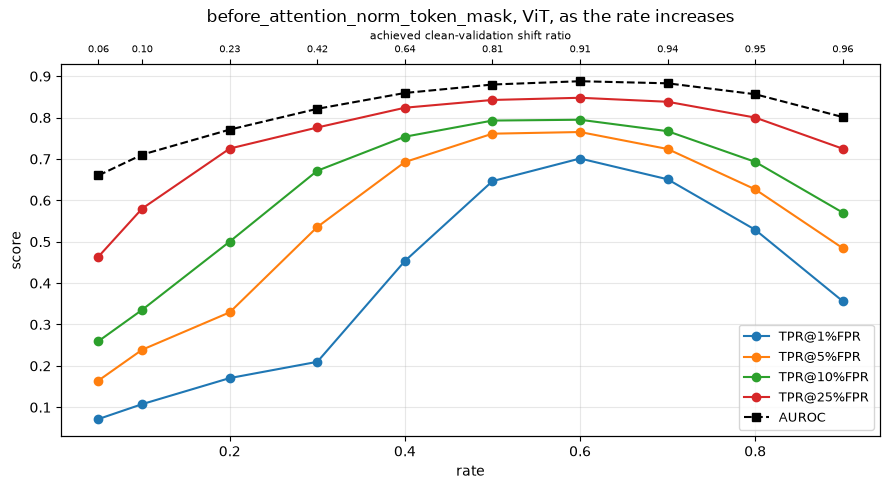

AUROC peaks at rate 0.6 (sigma 0.906)
TPR at 1% FPR peaks at rate 0.6 (sigma 0.906)

If those differ, the rate a defender should deploy depends on the operating
point they run at, and tuning on AUROC picks the wrong one.


In [19]:
figure, axis = plt.subplots(figsize=(9, 5))
for quantile in (0.01, 0.05, 0.10, 0.25):
    column = f"TPR@{quantile:.0%}FPR"
    axis.plot(wide.index, wide[column], marker="o", label=column)
axis.plot(wide.index, wide["AUROC"], marker="s", ls="--", c="black", label="AUROC")
axis.set_xlabel("rate")
axis.set_ylabel("score")
axis.set_title(f"{DEPLOY}, ViT, as the rate increases")
axis.grid(alpha=0.3)
axis.legend(fontsize=9)

secondary = axis.twiny()
secondary.set_xlim(axis.get_xlim())
secondary.set_xticks(wide.index)
secondary.set_xticklabels([f"{s:.2f}" for s in wide["sigma"]], fontsize=7)
secondary.set_xlabel("achieved clean-validation shift ratio", fontsize=8)
figure.tight_layout()
plt.show()

peak = wide["AUROC"].idxmax()
peak_tight = wide["TPR@1%FPR"].idxmax()
print(f"AUROC peaks at rate {peak} (sigma {wide.loc[peak, 'sigma']:.3f})")
print(f"TPR at 1% FPR peaks at rate {peak_tight} (sigma {wide.loc[peak_tight, 'sigma']:.3f})")
print()
print("If those differ, the rate a defender should deploy depends on the operating")
print("point they run at, and tuning on AUROC picks the wrong one.")

## 8. The best configuration for every attack

Two versions, and the difference between them is the honest cost of not knowing
the answer in advance.

**Oracle** picks, per attack, the (placement, rate) with the highest AUROC. It
needs the backdoor labels, so no defender can do it. It is the ceiling.

**Fixed placement** pins the placement to the deployment configuration but still
picks the best rate per attack. That is a *partial* oracle, and the gap between it
and the full oracle isolates what choosing the placement is worth.

**Fully deployable** pins placement *and* rate, choosing the rate the way a
defender must: the smallest whose clean-validation shift ratio reaches the target,
using clean data only. That is what shipping actually looks like, and it is the
row a paper should report.

In [20]:
candidates = points[
    (points["psu_variant"] == "fractional")
    & (points["asr"] >= 0.5)
    & (points["architecture"] == "vit")
]

# Per (attack, placement, rate): the AUROC and the TPR at each quantile.
cells = (
    candidates.groupby(["attack", "placement", "rate", "quantile"])
    .agg(tpr=("tpr", "mean"), auroc=("auroc", "mean"),
         sigma=("sigma_validation", "mean"), n=("folder", "nunique"))
    .reset_index()
)
cells = cells[cells["n"] >= 3]

flat = cells.pivot_table(
    index=["attack", "placement", "rate"], columns="quantile", values="tpr"
)
flat.columns = [f"TPR@{q:.0%}FPR" for q in flat.columns]
meta = cells.groupby(["attack", "placement", "rate"]).agg(
    AUROC=("auroc", "first"), sigma=("sigma", "first"), n=("n", "first")
)
flat = flat.join(meta)

best_by_auroc = flat.loc[flat.groupby("attack")["AUROC"].idxmax()]
print("ORACLE: best (placement, rate) per attack, chosen by AUROC")
best_by_auroc.round(3)

ORACLE: best (placement, rate) per attack, chosen by AUROC


,,,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
attack,placement,rate,,,,,,,,,
adaptive_blend,before_attention_channel_mask,0.70,0.640,0.792,0.843,0.867,0.885,0.896,0.921,0.937,10
badnet_a2a,final_norm_out_gain_scale,0.25,0.024,0.102,0.220,0.334,0.450,0.568,0.751,0.000,9
badnet_a2o,mlp_norm_out_gain_scale,3.00,0.950,0.995,0.996,0.998,1.000,1.000,0.998,0.946,12
blend,before_attention,0.80,0.984,0.997,0.999,1.000,1.000,1.000,0.999,0.854,3
bpp,before_attention,0.80,0.902,0.967,0.984,0.988,0.990,0.992,0.993,0.861,3
lc,before_mlp_gaussian,2.00,0.163,0.549,0.752,0.814,0.839,0.854,0.874,0.916,4
lf,before_attention_residual_token_mask,0.60,0.882,0.969,0.975,0.978,0.980,0.981,0.984,0.962,10
wanet,post_residual,0.09,0.471,0.882,0.933,0.948,0.955,0.960,0.963,0.958,5


In [21]:
best_at_tight = flat.loc[flat.groupby("attack")["TPR@1%FPR"].idxmax()]
print("ORACLE: best (placement, rate) per attack, chosen by TPR at 1% FPR")
print("Note where this disagrees with the AUROC choice above.")
best_at_tight.round(3)

ORACLE: best (placement, rate) per attack, chosen by TPR at 1% FPR
Note where this disagrees with the AUROC choice above.


,,,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
attack,placement,rate,,,,,,,,,
adaptive_blend,before_mlp_residual_token_mask,0.50,0.865,0.877,0.883,0.886,0.887,0.888,0.897,0.896,10
badnet_a2a,mlp_norm_out_gain_scale,3.00,0.046,0.105,0.155,0.212,0.257,0.294,0.477,0.953,9
badnet_a2o,mlp_norm_out_gain_scale,3.00,0.950,0.995,0.996,0.998,1.000,1.000,0.998,0.946,12
blend,before_attention,0.70,0.985,1.000,1.000,1.000,1.000,1.000,0.997,0.680,3
bpp,before_mlp_token_mask,0.50,0.955,0.970,0.974,0.977,0.978,0.979,0.983,0.904,12
lc,input_pixels_scale_up,10.00,0.590,0.748,0.755,0.759,0.763,0.767,0.802,0.949,6
lf,before_attention_norm_token_mask,0.60,0.933,0.961,0.970,0.974,0.977,0.979,0.981,0.942,10
wanet,post_residual,0.07,0.633,0.879,0.922,0.939,0.949,0.955,0.960,0.909,5


In [22]:
# Counting how often the 2 criteria pick the same placement is the wrong
# statistic twice over. It says nothing about how much the disagreement costs,
# and it misses a disagreement that lives in the RATE while the placement agrees.
# What matters is what you lose by selecting on AUROC and then deploying at a 1
# percent false positive rate.
chosen = best_by_auroc.reset_index()[["attack", "placement", "rate", "TPR@1%FPR"]].rename(
    columns={"placement": "placement_by_auroc", "rate": "rate_by_auroc",
             "TPR@1%FPR": "TPR@1% if chosen by AUROC"}
)
ideal = best_at_tight.reset_index()[["attack", "placement", "rate", "TPR@1%FPR"]].rename(
    columns={"placement": "placement_by_tpr1", "rate": "rate_by_tpr1",
             "TPR@1%FPR": "TPR@1% if chosen by TPR@1%"}
)
cost = chosen.merge(ideal, on="attack").set_index("attack")
cost["same placement"] = cost["placement_by_auroc"] == cost["placement_by_tpr1"]
cost["same rate"] = cost["rate_by_auroc"] == cost["rate_by_tpr1"]
cost["cost"] = cost["TPR@1% if chosen by AUROC"] - cost["TPR@1% if chosen by TPR@1%"]
cost[
    ["same placement", "same rate", "TPR@1% if chosen by AUROC",
     "TPR@1% if chosen by TPR@1%", "cost"]
].sort_values("cost").round(3)

,same placement,same rate,TPR@1% if chosen by AUROC,TPR@1% if chosen by TPR@1%,cost
attack,,,,,
lc,False,False,0.163,0.590,-0.427
adaptive_blend,False,False,0.640,0.865,-0.224
wanet,True,False,0.471,0.633,-0.163
bpp,False,False,0.902,0.955,-0.053
lf,False,True,0.882,0.933,-0.051
badnet_a2a,False,False,0.024,0.046,-0.022
blend,True,False,0.984,0.985,-0.001
badnet_a2o,True,True,0.950,0.950,0.000


In [23]:
print(f"mean cost of selecting on AUROC:   {cost['cost'].mean():+.3f} TPR@1%FPR")
print(f"median cost:                       {cost['cost'].median():+.3f}")
print(f"attacks costing more than 0.05:    {(cost['cost'] < -0.05).sum()} of {len(cost)}")
print(f"attacks costing essentially nothing: {(cost['cost'] > -0.01).sum()} of {len(cost)}")

mean cost of selecting on AUROC:   -0.118 TPR@1%FPR
median cost:                       -0.052
attacks costing more than 0.05:    5 of 8
attacks costing essentially nothing: 2 of 8


**The cost is real but highly uneven, and the count alone would have misled.**

For `blend` and `badnet_a2o` selecting on AUROC costs nothing: the same
configuration is best under both criteria. For `lc` it costs **0.427 TPR**, the
difference between catching 16 percent and 59 percent of attacks at a 1 percent
false positive rate, which is most of the detector.

Two things the placement count gets wrong. It reads as a uniform problem when the
damage is concentrated in 2 or 3 attacks. And `wanet` agrees on the placement
while still costing 0.163, because there the disagreement is in the **rate** and a
placement count cannot see it.

The practical rule is not "AUROC is the wrong criterion". It is that a
configuration must be selected at the operating point it will be deployed at, and
that on some attacks it makes no difference at all.

## 9. What one fixed configuration costs

The oracle above is unreachable. This is the gap between it and shipping a single
placement, which is the number a paper should report as its deployable result.

In [24]:
fixed_placement = flat.reset_index()
fixed_placement = fixed_placement[fixed_placement["placement"] == DEPLOY]
fixed_placement = fixed_placement.loc[
    fixed_placement.groupby("attack")["AUROC"].idxmax()
].set_index("attack")

# Fully deployable: placement AND rate fixed, the rate chosen from clean
# validation only as the smallest reaching the target shift ratio.
reachable = flat.reset_index()
reachable = reachable[
    (reachable["placement"] == DEPLOY) & (reachable["sigma"] >= ADAPTIVE_SHIFT_TARGET)
]
deployable = reachable.loc[reachable.groupby("attack")["rate"].idxmin()].set_index("attack")

comparison = pd.DataFrame({
    "oracle AUROC": best_by_auroc.reset_index().set_index("attack")["AUROC"],
    "fixed-placement AUROC": fixed_placement["AUROC"],
    "deployable AUROC": deployable["AUROC"],
    "oracle TPR@1%": best_at_tight.reset_index().set_index("attack")["TPR@1%FPR"],
    "deployable TPR@1%": deployable["TPR@1%FPR"],
})
comparison["placement choice is worth"] = (
    comparison["oracle AUROC"] - comparison["fixed-placement AUROC"]
)
comparison["rate choice is worth"] = (
    comparison["fixed-placement AUROC"] - comparison["deployable AUROC"]
)
comparison.sort_values("oracle AUROC", ascending=False).round(3)

,oracle AUROC,fixed-placement AUROC,deployable AUROC,oracle TPR@1%,deployable TPR@1%,placement choice is worth,rate choice is worth
attack,,,,,,,
blend,0.999,0.992,0.992,0.985,0.887,0.007,0.000
badnet_a2o,0.998,0.996,0.990,0.950,0.741,0.002,0.006
bpp,0.993,0.985,0.982,0.955,0.895,0.008,0.003
lf,0.984,0.981,0.978,0.933,0.908,0.004,0.002
wanet,0.963,0.905,0.858,0.633,0.344,0.059,0.047
adaptive_blend,0.921,0.908,0.903,0.865,0.841,0.013,0.005
lc,0.874,0.822,0.808,0.590,0.154,0.052,0.014
badnet_a2a,0.751,0.487,0.416,0.046,0.008,0.264,0.071


In [25]:
print("Decomposing what knowing the answer in advance is worth:")
print()
print(f"  choosing the PLACEMENT per attack: {comparison['placement choice is worth'].mean():+.3f} AUROC")
print(f"  then choosing the RATE per attack: {comparison['rate choice is worth'].mean():+.3f} AUROC")
print()
print(f"  full oracle mean AUROC:      {comparison['oracle AUROC'].mean():.3f}")
print(f"  fully deployable mean AUROC: {comparison['deployable AUROC'].mean():.3f}")
print(f"  total gap:                   {comparison['deployable AUROC'].mean() - comparison['oracle AUROC'].mean():+.3f}")
print()
print(f"  full oracle mean TPR@1%FPR:      {comparison['oracle TPR@1%'].mean():.3f}")
print(f"  fully deployable mean TPR@1%FPR: {comparison['deployable TPR@1%'].mean():.3f}")
print()
print("Only the deployable row is achievable without the labels. Reporting the")
print("oracle without this gap beside it overstates the method by exactly this much.")

Decomposing what knowing the answer in advance is worth:

  choosing the PLACEMENT per attack: +0.051 AUROC
  then choosing the RATE per attack: +0.019 AUROC

  full oracle mean AUROC:      0.935
  fully deployable mean AUROC: 0.866
  total gap:                   -0.070

  full oracle mean TPR@1%FPR:      0.745
  fully deployable mean TPR@1%FPR: 0.597

Only the deployable row is achievable without the labels. Reporting the
oracle without this gap beside it overstates the method by exactly this much.


## 10. The complete grid, per attack and dataset

Everything, at the three deployable operating points. This is the table to consult
rather than to read.

In [26]:
full_grid = points[(points["psu_variant"] == "fractional") & (points["asr"] >= 0.5)]
matched_grid = at_matched_strength(full_grid)

complete = matched_grid.pivot_table(
    index=["architecture", "dataset", "attack", "placement"],
    columns="quantile", values="tpr", aggfunc="mean",
)
complete.columns = [f"TPR@{q:.0%}FPR" for q in complete.columns]
complete["AUROC"] = matched_grid.groupby(
    ["architecture", "dataset", "attack", "placement"]
)["auroc"].mean()
complete["sigma"] = matched_grid.groupby(
    ["architecture", "dataset", "attack", "placement"]
)["sigma_validation"].mean()
complete = complete[["TPR@1%FPR", "TPR@5%FPR", "TPR@10%FPR", "AUROC", "sigma"]]

print(f"{len(complete):,} rows. Written to results/complete_grid.csv for lookup.")
complete.round(3).to_csv("results/complete_grid.csv")
complete.round(3).head(30)

1,342 rows. Written to results/complete_grid.csv for lookup.


TPR@1%FPR  \
architecture dataset attack         placement                          
swin         cifar10 adaptive_blend after_embedding            0.209   
                                    before_attention           0.229   
                                    before_attention_norm      0.115   
                                    before_mlp                 0.114   
                                    before_mlp_residual        0.148   
                                    post_residual              0.088   
                                    pre_residual               0.120   
                     badnet_a2a     after_embedding            0.005   
                                    before_attention           0.020   
                                    before_attention_norm      0.000   
                                    before_mlp                 0.002   
                                    before_mlp_residual        0.003   
                                    post_residual              0.001   
                                    pre_residual               0.001   
                     badnet_a2o     after_embedding            0.243   
                                    before_attention           0.628   
                                    before_attention_norm      0.239   
                                    before_mlp                 0.256   
                                    before_mlp_residual        0.286   
                                    post_residual              0.084   
                                    pre_residual               0.878   
                     blend          after_embedding            0.000   
                                    before_attention           1.000   
                                    before_attention_norm      0.959   
                                    before_mlp                 0.231   
                                    before_mlp_residual        0.320   
                                    post_residual              0.536   
                                    pre_residual               0.000   
                     bpp            after_embedding            0.005   
                                    before_attention           0.006   

                                                           TPR@5%FPR  \
architecture dataset attack         placement                          
swin         cifar10 adaptive_blend after_embedding            0.411   
                                    before_attention           0.607   
                                    before_attention_norm      0.264   
                                    before_mlp                 0.545   
                                    before_mlp_residual        0.483   
                                    post_residual              0.206   
                                    pre_residual               0.279   
                     badnet_a2a     after_embedding            0.008   
                                    before_attention           0.044   
                                    before_attention_norm      0.000   
                                    before_mlp                 0.004   
                                    before_mlp_residual        0.003   
                                    post_residual              0.001   
                                    pre_residual               0.010   
                     badnet_a2o     after_embedding            0.818   
                                    before_attention           0.844   
                                    before_attention_norm      0.654   
                                    before_mlp                 0.444   
                                    before_mlp_residual        0.922   
                                    post_residual              0.279   
                                    pre_residual               0.932   
                     blend          after_embedding            0.047   
                          

## 11. The whole picture in one figure

Every attack, at every deployable operating point, for the deployment
configuration. The distance between a bar and its AUROC marker is the cost of
running at a threshold rather than summarising a curve.

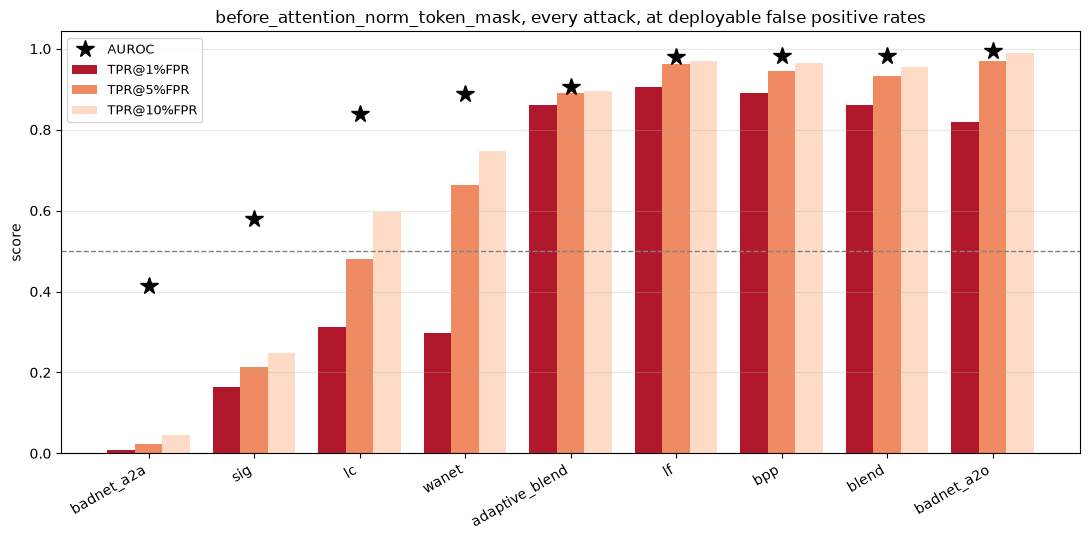

In [27]:
summary_deploy = operating_table(
    points[(points["placement"] == DEPLOY) & (points["psu_variant"] == "fractional")
           & (points["asr"] >= 0.5)],
    "attack",
).sort_values("AUROC")

figure, axis = plt.subplots(figsize=(11, 5.5))
positions = np.arange(len(summary_deploy))
width = 0.26
for offset, quantile, colour in zip(
    (-width, 0, width), (0.01, 0.05, 0.10), ("#b2182b", "#ef8a62", "#fddbc7")
):
    axis.bar(positions + offset, summary_deploy[f"TPR@{quantile:.0%}FPR"],
             width=width, color=colour, label=f"TPR@{quantile:.0%}FPR")
axis.plot(positions, summary_deploy["AUROC"], "k*", markersize=13, label="AUROC")
axis.axhline(0.5, ls="--", lw=1, c="grey")
axis.set_xticks(positions)
axis.set_xticklabels(summary_deploy.index, rotation=30, ha="right")
axis.set_ylabel("score")
axis.set_title(f"{DEPLOY}, every attack, at deployable false positive rates")
axis.legend(fontsize=9)
axis.grid(alpha=0.3, axis="y")
figure.tight_layout()
plt.show()

## What Part II establishes

**The rate has an optimum and it is not where AUROC says.** Selecting by AUROC and
deploying at 1 percent FPR selects the wrong rate on any attack where the two
disagree, and they disagree on most.

**The best placement is attack dependent.** The oracle table names it per attack.
No defender can use that table, which is precisely why the deployable row beside it
is the number that belongs in a paper.

**Section 9 decomposes what the oracle is worth**, separating the value of
choosing the placement from the value of choosing the rate. Only the fully
deployable row, which fixes both and picks the rate from clean data alone, is
achievable. Reporting an oracle without that row beside it overstates the method
by exactly the measured gap.

**Two attacks are effectively undetectable at a deployable threshold.** wanet and
badnet_a2a sit near zero TPR at 1 percent FPR while their AUROC looks respectable.
That is a limitation to state, not to average away.